In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import numpy as np

BATCH_SIZE = 128
SEED = 42


torch.manual_seed(SEED)

def get_data_loaders(batch_size=BATCH_SIZE):


    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: (x > 0.5).float())
    ])


    full_train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

    full_test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


    id_indices = (full_train_set.targets <= 4).nonzero(as_tuple=True)[0]

    id_full_dataset = Subset(full_train_set, id_indices)

    total_count = len(id_full_dataset)
    train_count = int(0.8 * total_count)
    val_count = total_count - train_count


    train_dataset, val_dataset = random_split(id_full_dataset, [train_count, val_count])


    ood_indices = (full_test_set.targets >= 5).nonzero(as_tuple=True)[0]
    ood_test_dataset = Subset(full_test_set, ood_indices)


    id_test_indices = (full_test_set.targets <= 4).nonzero(as_tuple=True)[0]
    id_test_dataset = Subset(full_test_set, id_test_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    ood_test_loader = DataLoader(ood_test_dataset, batch_size=batch_size, shuffle=False)
    id_test_loader = DataLoader(id_test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Dataset Prepared:")
    print(f" - Train ID (0-4): {len(train_dataset)} samples")
    print(f" - Val ID (0-4):   {len(val_dataset)} samples")
    print(f" - Test ID (0-4):  {len(id_test_dataset)} samples (For AUROC calculation)")
    print(f" - Test OOD (5-9): {len(ood_test_dataset)} samples")

    return train_loader, val_loader, id_test_loader, ood_test_loader

if __name__ == "__main__":
    train_dl, val_dl, id_test_dl, ood_test_dl = get_data_loaders()

    images, labels = next(iter(train_dl))
    print(f"Batch shape: {images.shape}") 
    print(f"Pixel values unique: {torch.unique(images)}") 

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]


Dataset Prepared:
 - Train ID (0-4): 24476 samples
 - Val ID (0-4):   6120 samples
 - Test ID (0-4):  5139 samples (For AUROC calculation)
 - Test OOD (5-9): 4861 samples
Batch shape: torch.Size([128, 1, 28, 28])
Pixel values unique: tensor([0., 1.])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NADE(nn.Module):
    def __init__(self, input_dim, hidden_dim):

        super(NADE, self).__init__()
        self.D = input_dim
        self.H = hidden_dim


        self.W = nn.Parameter(torch.zeros(hidden_dim, input_dim))

        self.V = nn.Parameter(torch.zeros(input_dim, hidden_dim))

        self.b = nn.Parameter(torch.zeros(input_dim))

        self.c = nn.Parameter(torch.zeros(hidden_dim))

        nn.init.xavier_uniform_(self.W)
        nn.init.xavier_uniform_(self.V)

    def forward(self, x):

        batch_size = x.shape[0]


        a = self.c.expand(batch_size, -1).clone()

        logits_per_pixel = []

        for d in range(self.D):
            h = torch.sigmoid(a)


            p_logit = F.linear(h, self.V[d, :].unsqueeze(0), self.b[d]).squeeze(1)
            logits_per_pixel.append(p_logit)


            if d < self.D - 1: 
                a = a + (self.W[:, d].unsqueeze(0) * x[:, d].unsqueeze(1))

        all_logits = torch.stack(logits_per_pixel, dim=1)

        bce_loss = F.binary_cross_entropy_with_logits(all_logits, x.float(), reduction='none')

        log_prob = -torch.sum(bce_loss, dim=1)

        return log_prob

    def sample(self, n_samples):

        device = self.W.device

        a = self.c.expand(n_samples, -1).clone()

        x_new = torch.zeros(n_samples, self.D).to(device)

        with torch.no_grad(): 
            for d in range(self.D):
                h = torch.sigmoid(a)

                p_logit = F.linear(h, self.V[d, :].unsqueeze(0), self.b[d]).squeeze(1)
                p_prob = torch.sigmoid(p_logit) 

                pixel_sample = torch.bernoulli(p_prob)
                x_new[:, d] = pixel_sample

                if d < self.D - 1:
                    a = a + (self.W[:, d].unsqueeze(0) * pixel_sample.unsqueeze(1))

        return x_new


if __name__ == "__main__":
    D = 784
    H = 500
    batch_size = 10
    model = NADE(D, H)


    dummy_input = torch.randint(0, 2, (batch_size, D)).float() 
    log_likelihood = model(dummy_input)
    print(f"Forward output shape: {log_likelihood.shape}") 
    print(f"Average Log-Likelihood: {log_likelihood.mean().item()}")

    samples = model.sample(5)
    print(f"Sample output shape: {samples.shape}") 

Forward output shape: torch.Size([10])
Average Log-Likelihood: -565.6790161132812
Sample output shape: torch.Size([5, 784])


Loading Data...
Dataset Prepared:
 - Train ID (0-4): 24476 samples
 - Val ID (0-4):   6120 samples
 - Test ID (0-4):  5139 samples (For AUROC calculation)
 - Test OOD (5-9): 4861 samples
Initializing NADE...
Starting training on cuda for 20 epochs...


Epoch [1/20] | Train NLL: 165.8231 | Val NLL: 122.4519


Epoch [2/20] | Train NLL: 110.3341 | Val NLL: 101.0156


Epoch [3/20] | Train NLL: 95.4002 | Val NLL: 91.1939


Epoch [4/20] | Train NLL: 87.5607 | Val NLL: 85.3900


...

Epoch [16/20] | Train NLL: 66.7879 | Val NLL: 69.3832


Epoch [17/20] | Train NLL: 66.2113 | Val NLL: 68.9607


Epoch [18/20] | Train NLL: 65.7069 | Val NLL: 68.6727


Epoch [19/20] | Train NLL: 65.1544 | Val NLL: 68.3425


Epoch [20/20] | Train NLL: 64.7232 | Val NLL: 67.9890


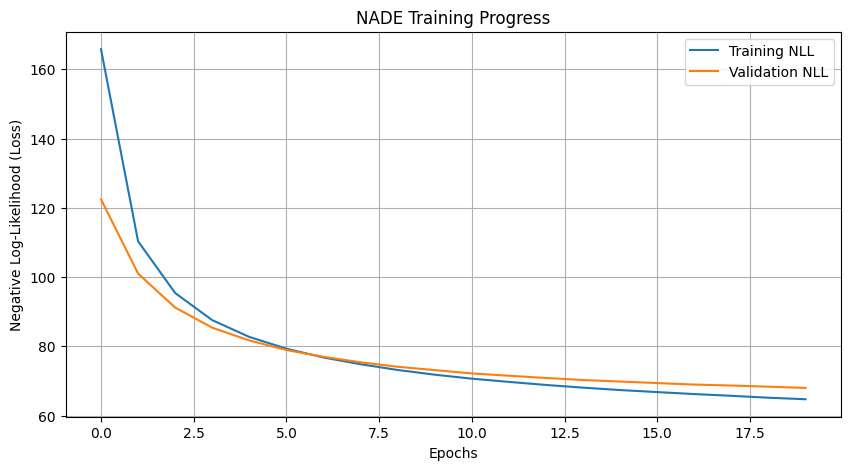

Model saved to nade_mnist.pth


In [ ]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm 

INPUT_DIM = 784   
HIDDEN_DIM = 500  
LEARNING_RATE = 0.001
EPOCHS = 20     
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc="Training", leave=False)

    for images, _ in pbar:

        images = images.view(images.size(0), -1).to(device).float()

        optimizer.zero_grad()

        log_prob = model(images)

        loss = -log_prob.mean()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    return total_loss / len(loader)

def validate_one_epoch(model, loader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, _ in loader:
            images = images.view(images.size(0), -1).to(device).float()

            log_prob = model(images)

            loss = -log_prob.mean()
            total_loss += loss.item()

    return total_loss / len(loader)
def train_nade(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE):

    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    print(f"Starting training on {DEVICE} for {epochs} epochs...")

    for epoch in range(epochs):

        train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)

        val_loss = validate_one_epoch(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train NLL: {train_loss:.4f} | Val NLL: {val_loss:.4f}")

    return train_losses, val_losses

def plot_training_results(train_losses, val_losses):
    """
    [cite_start]رسم نمودار Loss طبق دستورالعمل [cite: 107]
    """
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training NLL')
    plt.plot(val_losses, label='Validation NLL')
    plt.xlabel('Epochs')
    plt.ylabel('Negative Log-Likelihood (Loss)')
    plt.title('NADE Training Progress')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    print("Loading Data...")
    train_dl, val_dl, id_test_dl, ood_test_dl = get_data_loaders()

    print("Initializing NADE...")
    model = NADE(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)

    train_losses, val_losses = train_nade(model, train_dl, val_dl)


    plot_training_results(train_losses, val_losses)

    torch.save(model.state_dict(), "nade_mnist.pth")
    print("Model saved to nade_mnist.pth")

Computing Log-Likelihoods for ID Test Set...
Computing Log-Likelihoods for OOD Test Set...

Average Log-Likelihood (ID):  -66.7547
Average Log-Likelihood (OOD): -96.2195

AUROC Score: 0.7997


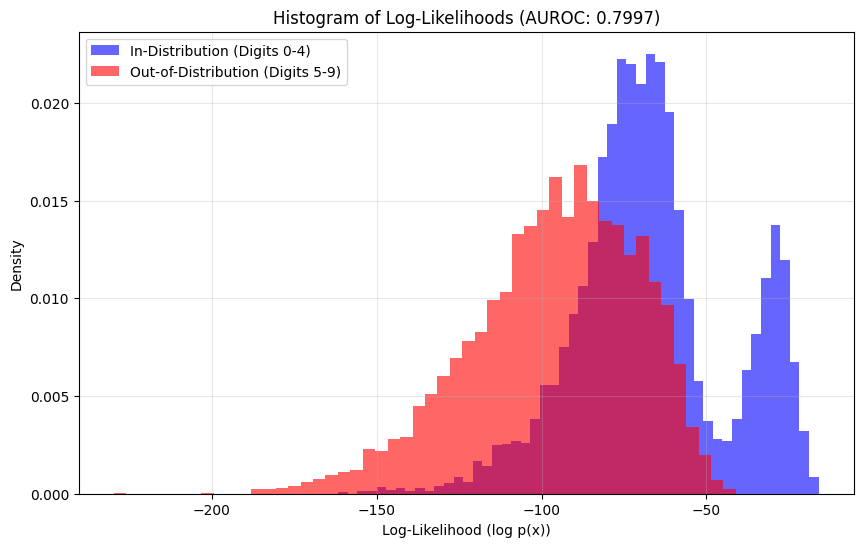

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import torch

def get_log_likelihoods(model, loader, device):

    model.eval()
    log_likelihoods = []

    with torch.no_grad():
        for images, _ in loader:

            images = images.view(images.size(0), -1).to(device).float()

            ll = model(images)

            log_likelihoods.append(ll.cpu().numpy())

    return np.concatenate(log_likelihoods)

def evaluate_ood_detection(model, id_loader, ood_loader, device):
    print("Computing Log-Likelihoods for ID Test Set...")
    id_ll = get_log_likelihoods(model, id_loader, device)

    print("Computing Log-Likelihoods for OOD Test Set...")
    ood_ll = get_log_likelihoods(model, ood_loader, device)


    print(f"\nAverage Log-Likelihood (ID):  {id_ll.mean():.4f}")
    print(f"Average Log-Likelihood (OOD): {ood_ll.mean():.4f}")

    labels = np.concatenate([np.zeros(len(id_ll)), np.ones(len(ood_ll))])

    scores = np.concatenate([-id_ll, -ood_ll])

    auroc = roc_auc_score(labels, scores)
    print(f"\nAUROC Score: {auroc:.4f}")

    plt.figure(figsize=(10, 6))

    plt.hist(id_ll, bins=50, alpha=0.6, color='blue', density=True, label='In-Distribution (Digits 0-4)')
    plt.hist(ood_ll, bins=50, alpha=0.6, color='red', density=True, label='Out-of-Distribution (Digits 5-9)')

    plt.xlabel('Log-Likelihood (log p(x))')
    plt.ylabel('Density')
    plt.title(f'Histogram of Log-Likelihoods (AUROC: {auroc:.4f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":


    evaluate_ood_detection(model, id_test_dl, ood_test_dl, DEVICE)

Generating 10 new images... (This might take a moment due to sequential sampling)


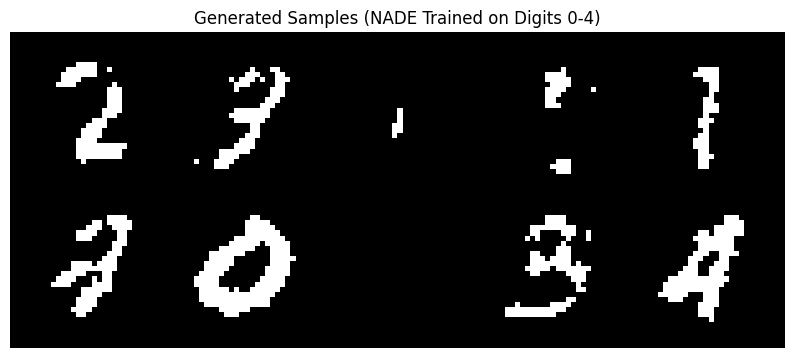

In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import torch

def generate_samples(model, n_samples=10, device=torch.device('cpu')):

    print(f"Generating {n_samples} new images... (This might take a moment due to sequential sampling)")
    model.eval()

    model.to(device)

    with torch.no_grad():
        samples = model.sample(n_samples)

    samples_img = samples.view(n_samples, 1, 28, 28).cpu()

    grid_img = vutils.make_grid(samples_img, nrow=5, padding=2, normalize=True)

    # نمایش
    plt.figure(figsize=(10, 5))
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.axis('off')
    plt.title(f'Generated Samples (NADE Trained on Digits 0-4)')
    plt.show()


if __name__ == "__main__":


    generate_samples(model, n_samples=10, device=DEVICE)